In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/House Price Prediction.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(2000, 10)
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
X = df[['Area', 'Bedrooms']]
y = df['Price']
print(X)
print(y)
print(df.columns)

      Area  Bedrooms
0     1360         5
1     4272         5
2     3592         2
3      966         4
4     4926         1
...    ...       ...
1995  4994         5
1996  3046         5
1997  1062         5
1998  4062         3
1999  2989         5

[2000 rows x 2 columns]
0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[536547.37222376 535952.18636494 536431.80421459 536380.72626951
 536253.4146584 ]


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 77856354491.90523


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.0007394195144101445


In [ ]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
1860,514764,536547.372224
353,694256,535952.186365
1333,66375,536431.804215
905,650243,536380.726270
1289,223285,536253.414658
1273,468127,536132.456937
938,513002,536206.252331
1731,911525,536101.730086
65,723265,536399.117929
1323,339416,535921.124510


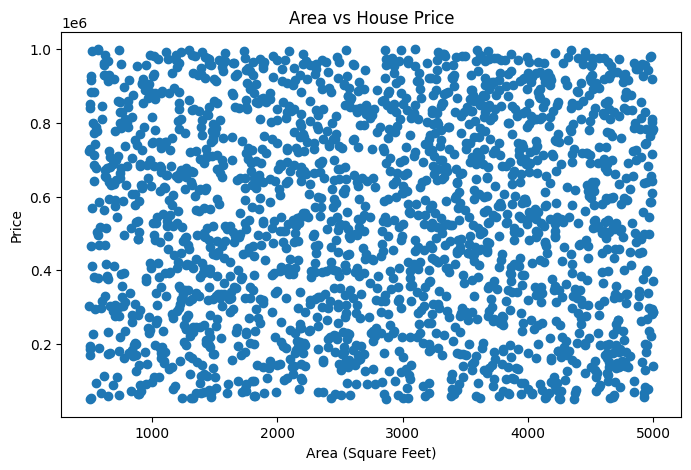

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Area'], df['Price'])

plt.xlabel("Area (Square Feet)")
plt.ylabel("Price")

plt.title("Area vs House Price")

plt.show()

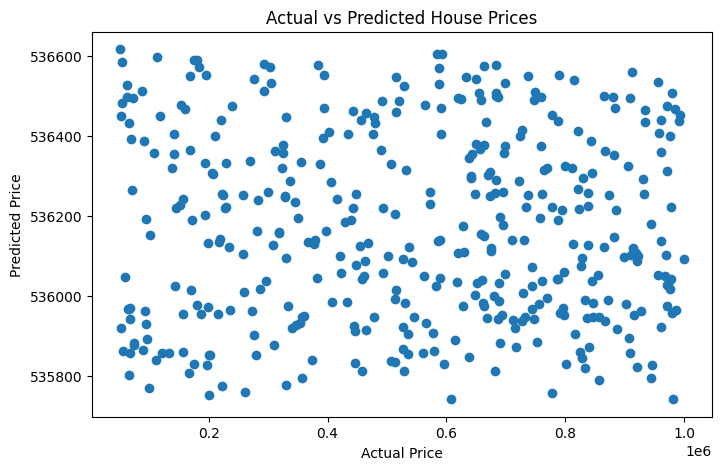

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
custom_house = [[2000, 3]]

custom_house = scaler.transform(custom_house)

predicted_price = model.predict(custom_house)

print("Predicted House Price = ₹", predicted_price[0])

Predicted House Price = ₹ 536326.2491276069


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
area = float(input("Enter Area: "))
rooms = int(input("Enter Number of Rooms: "))

new_house = [[area, rooms]]

new_house = scaler.transform(new_house)

price = model.predict(new_house)

print("\nPredicted House Price: ₹", round(price[0],2))

Enter Area: 100
Enter Number of Rooms: 4

Predicted House Price: ₹ 536692.78


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
